# Import Dataset from Kaggle

In [ ]:
import kagglehub

# Download latest version of Carla Self Steering Dataset
self_steering_data_path = kagglehub.dataset_download("zahidbooni/alltownswithweather ")
print("Path to Carla Self Steering Dataset files:", self_steering_data_path)

100%|██████████| 11.0G/11.0G [01:58<00:00, 99.9MB/s]

Extracting files...


Path to Carla Self Steering Dataset files: /root/.cache/kagglehub/datasets/zahidbooni/alltownswithweather /versions/4


100%|██████████| 27.1M/27.1M [00:00<00:00, 52.5MB/s]

Extracting files...


Path to Carla Object Detection Dataset files: /root/.cache/kagglehub/datasets/ibrahimalobaid/object-detection-carla-self-driving-car/versions/1
Mounted at /content/drive


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Deep Learning Imports and Initialize to T4 Runtime

In [ ]:
import os
from pathlib import Path
import time
import shutil

# Deep Learning Imports
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt

from PIL import Image

# Allow for T4 GPU compatibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0))

cuda
Tesla T4


# Data Loader & Train Functions

In [ ]:
# @title
STEERING_CACHE_VERSION = 4
STEERING_FRAME_STRIDE = 4  # 1 uses every frame; 2 every second frame; etc.
STEERING_INPUT_MODE = "roi"  # "roi" uses roicropped/roicropped; "full" uses Data/Images
STEERING_SOURCE_IMAGE_SIZE = (220, 220)  # H, W before the lower-half ROI crop
STEERING_ROI_CROP = (0, 110, 220, 220)  # left, top, right, bottom in source pixels
_STEERING_DATASET_CACHE = {}
img_size = (110, 220)  # H, W of the existing ROI-cropped RGB images


class CachedSteeringDataset(Dataset):
    """Compact uint8 images with continuous steering-value targets."""

    def __init__(self, images_uint8, steering_values):
        if images_uint8.dtype != torch.uint8:
            raise TypeError("Cached images must use torch.uint8")
        if images_uint8.ndim != 4 or images_uint8.shape[1] != 3:
            raise ValueError(
                f"Expected cached images shaped [N, 3, H, W], got {images_uint8.shape}"
            )

        self.images_uint8 = images_uint8
        self.steering_values = steering_values.float().reshape(-1)

        if len(self.images_uint8) != len(self.steering_values):
            raise ValueError("Cached image and steering-value counts do not match")

    def __len__(self):
        return len(self.images_uint8)

    def __getitem__(self, index):
        # Keep samples as uint8. The training loop converts complete batches on GPU.
        return self.images_uint8[index], self.steering_values[index]


def _normalise_folder_name(name):
    return "".join(character.lower() for character in name if character.isalnum())


def _find_steering_images_dir(dataset_root, input_mode):
    dataset_root = Path(dataset_root)
    mode = str(input_mode).strip().lower()
    if mode not in {"roi", "full"}:
        raise ValueError("input_mode must be 'roi' or 'full'")

    candidates = (
        [
            dataset_root / "roicropped" / "roicropped",
            dataset_root / "roicropped",
        ]
        if mode == "roi"
        else [
            dataset_root / "Data" / "Images",
            dataset_root / "Data" / "images",
        ]
    )
    for candidate in candidates:
        if candidate.is_dir() and any(candidate.glob("image*.png")):
            return candidate

    expected_name = "roicropped" if mode == "roi" else "images"
    matches = [
        path
        for path in dataset_root.rglob("*")
        if (
            path.is_dir()
            and _normalise_folder_name(path.name) == expected_name
            and any(path.glob("image*.png"))
        )
    ]
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Could not uniquely locate {mode!r} steering images under "
            f"{dataset_root}. Expected ROI images at "
            f"{dataset_root / 'roicropped' / 'roicropped'}."
        )
    return matches[0]


def _steering_source_files(
    dataset_root,
    frame_stride=1,
    input_mode=STEERING_INPUT_MODE,
):
    dataset_root = Path(dataset_root)
    images_dir = _find_steering_images_dir(dataset_root, input_mode)
    labels_path = dataset_root / "Data" / "SteerValues" / "steer_values.txt"

    if frame_stride < 1:
        raise ValueError("frame_stride must be at least 1")
    if not images_dir.is_dir():
        raise FileNotFoundError(f"Image directory not found: {images_dir}")
    if not labels_path.is_file():
        raise FileNotFoundError(f"Steering labels not found: {labels_path}")

    image_paths = sorted(
        images_dir.glob("image*.png"),
        key=lambda path: int("".join(filter(str.isdigit, path.stem))),
    )
    steering_values = torch.from_numpy(
        np.asarray(np.loadtxt(labels_path, dtype=np.float32), dtype=np.float32)
    ).reshape(-1)

    if len(image_paths) != len(steering_values):
        raise ValueError(
            f"Found {len(image_paths)} images but {len(steering_values)} steering values"
        )

    # Select matching image/label pairs before splitting. Both models reuse this.
    image_paths = image_paths[::frame_stride]
    steering_values = steering_values[::frame_stride].contiguous()
    return image_paths, steering_values


def _steering_cache_path(image_size, frame_stride, input_mode):
    height, width = map(int, image_size)

    drive_root = Path("/content/drive/MyDrive/NavisAI/cache")
    cache_root = (
        drive_root
        if Path("/content/drive/MyDrive").is_dir()
        else Path("/content/navisai_cache")
    )
    cache_root.mkdir(parents=True, exist_ok=True)
    return cache_root / (
        f"steering_{input_mode}_{height}x{width}_stride{frame_stride}_uint8_"
        f"v{STEERING_CACHE_VERSION}.pt"
    )


def _load_tensor_cache(cache_path, image_size, expected_count, input_mode):
    try:
        try:
            payload = torch.load(cache_path, map_location="cpu", weights_only=True)
        except TypeError:
            payload = torch.load(cache_path, map_location="cpu")

        images_uint8 = payload["images_uint8"]
        steering_values = payload["steering_values"]
        cached_size = tuple(payload["image_size"])
        cached_input_mode = payload.get("input_mode")

        if cached_input_mode != input_mode:
            raise ValueError(
                f"Cache input mode is {cached_input_mode!r}, not {input_mode!r}"
            )
        if cached_size != tuple(image_size):
            raise ValueError(f"Cache image size is {cached_size}, not {tuple(image_size)}")
        if len(images_uint8) != expected_count or len(steering_values) != expected_count:
            raise ValueError("Cache sample count does not match the selected source data")

        print(f"Loaded {expected_count:,} preprocessed steering images from {cache_path}")
        return CachedSteeringDataset(images_uint8, steering_values)
    except Exception as error:
        print(f"Ignoring invalid steering cache ({error}); rebuilding it once.")
        cache_path.unlink(missing_ok=True)
        return None


def prepare_steering_cache(
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    force_rebuild=False,
):
    """Build once, then reuse identical ROI frame/label pairs for both models."""

    image_size = tuple(map(int, image_size))
    frame_stride = int(frame_stride)
    input_mode = str(input_mode).strip().lower()
    if input_mode == "roi" and image_size != (110, 220):
        raise ValueError("ROI mode requires image_size=(110, 220)")
    memory_key = (
        str(Path(self_steering_data_path)),
        input_mode,
        image_size,
        frame_stride,
    )

    if not force_rebuild and memory_key in _STEERING_DATASET_CACHE:
        return _STEERING_DATASET_CACHE[memory_key]

    image_paths, steering_values = _steering_source_files(
        self_steering_data_path,
        frame_stride=frame_stride,
        input_mode=input_mode,
    )
    cache_path = _steering_cache_path(image_size, frame_stride, input_mode)

    if cache_path.is_file() and not force_rebuild:
        dataset = _load_tensor_cache(
            cache_path,
            image_size,
            len(image_paths),
            input_mode,
        )
        if dataset is not None:
            _STEERING_DATASET_CACHE[memory_key] = dataset
            return dataset

    height, width = image_size
    images_uint8 = torch.empty(
        (len(image_paths), 3, height, width),
        dtype=torch.uint8,
    )

    print(
        f"Preprocessing {len(image_paths):,} selected steering images once "
        f"(every {frame_stride} frame(s))."
    )
    started = time.time()

    for index, image_path in enumerate(image_paths):
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = image.resize((width, height), Image.Resampling.BILINEAR)
            images_uint8[index] = TF.pil_to_tensor(image)

        if (index + 1) % 5000 == 0 or index + 1 == len(image_paths):
            print(f"Cached {index + 1:,}/{len(image_paths):,} images")

    temporary_path = cache_path.with_suffix(cache_path.suffix + ".tmp")
    torch.save(
        {
            "cache_version": STEERING_CACHE_VERSION,
            "image_size": image_size,
            "frame_stride": frame_stride,
            "input_mode": input_mode,
            "source_image_size": STEERING_SOURCE_IMAGE_SIZE,
            "roi_crop": STEERING_ROI_CROP if input_mode == "roi" else None,
            "images_uint8": images_uint8,
            "steering_values": steering_values,
        },
        temporary_path,
    )
    os.replace(temporary_path, cache_path)

    elapsed = (time.time() - started) / 60
    size_mb = cache_path.stat().st_size / (1024 ** 2)
    print(
        f"Steering cache saved to {cache_path} "
        f"({size_mb:.1f} MiB, {elapsed:.2f} minutes)."
    )

    dataset = CachedSteeringDataset(images_uint8, steering_values)
    _STEERING_DATASET_CACHE[memory_key] = dataset
    return dataset


def get_stirdata_loader(
    batch_size,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    split_seed=1000,
):
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1")

    dataset = prepare_steering_cache(
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
    )
    dataset_size = len(dataset)
    train_size = int(train_ratio * dataset_size)
    val_size = int(val_ratio * dataset_size)
    test_size = dataset_size - train_size - val_size

    split_generator = torch.Generator().manual_seed(split_seed)
    train_dataset, val_dataset, test_dataset = random_split(
        dataset,
        [train_size, val_size, test_size],
        generator=split_generator,
    )

    loader_options = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
    )
    if num_workers > 0:
        loader_options["persistent_workers"] = True
        loader_options["prefetch_factor"] = 2

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        generator=torch.Generator().manual_seed(split_seed),
        **loader_options,
    )
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

    print(
        f"Steering samples: train={train_size:,}, validation={val_size:,}, "
        f"test={test_size:,}; input_mode={input_mode}; "
        f"image_size={tuple(image_size)}; frame_stride={frame_stride}; "
        f"uint8 cache=True"
    )
    return train_loader, val_loader, test_loader

In [ ]:
def _new_grad_scaler(amp_enabled):
    # Supports both current and older PyTorch versions available in Colab.
    try:
        return torch.amp.GradScaler("cuda", enabled=amp_enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=amp_enabled)


def _steering_batch_to_device(images, steering_values):
    # Transfer compact uint8 first, then convert the complete batch on the GPU.
    images = images.to(device, non_blocking=True)
    images = images.float().div_(255.0)
    targets = steering_values.to(device, non_blocking=True).float().view(-1, 1)
    return images, targets


def stir_train(
    model,
    batch_size=128,
    learning_rate=0.001,
    num_epochs=10,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
    model_name="SteeringModel",
    checkpoint_stem="steering_model",
):
    """Shared MSE loop with GPU batch conversion and mixed precision."""

    train_loader, val_loader, test_loader = get_stirdata_loader(
        batch_size=batch_size,
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
        num_workers=num_workers,
    )

    train_losses = []
    val_losses = []
    criterion = nn.SmoothL1Loss(beta=0.05)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    checkpoint_root = (
        Path("/content/drive/MyDrive/NavisAI/models")
        if Path("/content/drive/MyDrive").is_dir()
        else Path("/content/navisai_checkpoints")
    )
    checkpoint_root.mkdir(parents=True, exist_ok=True)
    best_checkpoint_path = checkpoint_root / f"{checkpoint_stem}_best.pt"
    final_checkpoint_path = checkpoint_root / f"{checkpoint_stem}_final.pt"
    best_val_loss = float("inf")

    def save_checkpoint(path, epoch, validation_mse):
        temporary_path = path.with_suffix(path.suffix + ".tmp")
        torch.save(
            {
                "checkpoint_version": 2,
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "epoch": int(epoch),
                "validation_mse": float(validation_mse),
                "image_size": tuple(image_size),
                "input_height": int(image_size[0]),
                "input_width": int(image_size[1]),
                "input_channels": 3,
                "input_mode": str(input_mode),
                "source_image_size": tuple(STEERING_SOURCE_IMAGE_SIZE),
                "roi_crop": (
                    tuple(STEERING_ROI_CROP)
                    if str(input_mode).lower() == "roi"
                    else None
                ),
                "pixel_range": (0.0, 1.0),
                "frame_stride": int(frame_stride),
                "split_seed": 1000,
                "batch_size": int(batch_size),
                "learning_rate": float(learning_rate),
                "train_losses": list(train_losses),
                "val_losses": list(val_losses),
            },
            temporary_path,
        )
        os.replace(temporary_path, path)

    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = _new_grad_scaler(amp_enabled)
    print(f"Mixed precision enabled: {amp_enabled}")
    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_started = time.time()
        model.train()
        running_train_loss = 0.0
        train_total = 0

        for images, steering_values in train_loader:
            images, steering_values = _steering_batch_to_device(
                images, steering_values
            )
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)
                if predictions.shape != steering_values.shape:
                    raise ValueError(
                        f"Prediction shape {predictions.shape} does not match "
                        f"target shape {steering_values.shape}"
                    )
                loss = criterion(predictions, steering_values)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_train_loss += loss.detach().float().item() * images.size(0)
            train_total += images.size(0)

        average_train_loss = running_train_loss / max(train_total, 1)
        train_losses.append(average_train_loss)

        model.eval()
        running_val_loss = 0.0
        val_total = 0

        with torch.inference_mode():
            for images, steering_values in val_loader:
                images, steering_values = _steering_batch_to_device(
                    images, steering_values
                )
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=amp_enabled,
                ):
                    predictions = model(images)
                    loss = criterion(predictions, steering_values)

                running_val_loss += loss.float().item() * images.size(0)
                val_total += images.size(0)

        average_val_loss = running_val_loss / max(val_total, 1)
        val_losses.append(average_val_loss)
        scheduler.step(average_val_loss)
        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss
            save_checkpoint(
                best_checkpoint_path,
                epoch=epoch + 1,
                validation_mse=average_val_loss,
            )
            print(f"Saved new best checkpoint: {best_checkpoint_path}")
        epoch_seconds = time.time() - epoch_started

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"training MSE={average_train_loss:.6f} | "
            f"validation MSE={average_val_loss:.6f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | "
            f"time={epoch_seconds:.1f}s"
        )

    save_checkpoint(
        final_checkpoint_path,
        epoch=num_epochs,
        validation_mse=val_losses[-1],
    )
    try:
        best_payload = torch.load(
            best_checkpoint_path,
            map_location=device,
            weights_only=True,
        )
    except TypeError:
        best_payload = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(best_payload["model_state_dict"])
    print("Restored the best-validation weights for evaluation.")

    elapsed_minutes = (time.time() - start_time) / 60
    print(f"Training took {elapsed_minutes:.2f} minutes.")
    print(f"Best checkpoint: {best_checkpoint_path}")
    print(f"Final checkpoint: {final_checkpoint_path}")
    return train_losses, val_losses


def evaluate_steering_model(
    model,
    batch_size=128,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
):
    """Evaluate on the same deterministic selected-frame test split."""

    _, _, test_loader = get_stirdata_loader(
        batch_size=batch_size,
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
        num_workers=num_workers,
    )

    squared_error_sum = 0.0
    absolute_error_sum = 0.0
    total = 0
    amp_enabled = bool(use_amp and device.type == "cuda")
    model.eval()

    with torch.inference_mode():
        for images, steering_values in test_loader:
            images, targets = _steering_batch_to_device(images, steering_values)
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)
            errors = predictions.float() - targets.float()

            squared_error_sum += errors.square().sum().item()
            absolute_error_sum += errors.abs().sum().item()
            total += targets.numel()

    metrics = {
        "test_mse": squared_error_sum / max(total, 1),
        "test_mae": absolute_error_sum / max(total, 1),
    }
    print(
        f"Test MSE={metrics['test_mse']:.6f} | "
        f"Test MAE={metrics['test_mae']:.6f}"
    )
    return metrics


In [ ]:
def steering_accuracy_report(
    model,
    model_name,
    batch_size=256,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
):
    """
    Evaluate a steering-regression model on the deterministic test split.

    Tolerance accuracy is the percentage of predictions whose absolute error
    is no greater than the specified steering tolerance.
    """

    _, _, test_loader = get_stirdata_loader(
        batch_size=batch_size,
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
        num_workers=num_workers,
    )

    squared_error_sum = 0.0
    absolute_error_sum = 0.0
    target_sum = 0.0
    target_squared_sum = 0.0

    within_005 = 0
    within_010 = 0
    total_predictions = 0

    amp_enabled = bool(use_amp and device.type == "cuda")
    model.eval()

    with torch.inference_mode():
        for images, steering_values in test_loader:
            images, targets = _steering_batch_to_device(
                images,
                steering_values,
            )

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)

            predictions = predictions.float().view(-1)
            targets = targets.float().view(-1)
            errors = predictions - targets
            absolute_errors = errors.abs()

            squared_error_sum += errors.square().sum().item()
            absolute_error_sum += absolute_errors.sum().item()

            target_sum += targets.sum().item()
            target_squared_sum += targets.square().sum().item()

            within_005 += (absolute_errors <= 0.05).sum().item()
            within_010 += (absolute_errors <= 0.10).sum().item()
            total_predictions += targets.numel()

    mse = squared_error_sum / max(total_predictions, 1)
    rmse = mse ** 0.5
    mae = absolute_error_sum / max(total_predictions, 1)

    # Total variation of the test-set steering targets.
    total_target_variation = (
        target_squared_sum
        - (target_sum ** 2 / max(total_predictions, 1))
    )

    r_squared = (
        1.0 - squared_error_sum / total_target_variation
        if total_target_variation > 0
        else float("nan")
    )

    accuracy_005 = 100.0 * within_005 / max(total_predictions, 1)
    accuracy_010 = 100.0 * within_010 / max(total_predictions, 1)

    results = {
        "model": model_name,
        "test_samples": total_predictions,
        "test_mse": mse,
        "test_rmse": rmse,
        "test_mae": mae,
        "r_squared": r_squared,
        "accuracy_within_0.05": accuracy_005,
        "accuracy_within_0.10": accuracy_010,
    }

    print(f"\n{model_name} test-set performance")
    print("-" * 45)
    print(f"Test samples:              {total_predictions:,}")
    print(f"MSE:                       {mse:.6f}")
    print(f"RMSE:                      {rmse:.6f}")
    print(f"MAE:                       {mae:.6f}")
    print(f"R²:                        {r_squared:.4f}")
    print(f"Accuracy within ±0.05:     {accuracy_005:.2f}%")
    print(f"Accuracy within ±0.10:     {accuracy_010:.2f}%")

    return results

In [ ]:
# Build or load the shared steering-image cache before either model trains.
# The first run preprocesses the PNG files once; later runs load one compact tensor file.
shared_steering_dataset = prepare_steering_cache(image_size=img_size)
print(f"Shared cached steering samples: {len(shared_steering_dataset):,}")


Loaded 21,623 preprocessed steering images from /content/drive/MyDrive/NavisAI/cache/steering_roi_110x220_stride4_uint8_v4.pt
Shared cached steering samples: 21,623


# NavisSteer Model

In [ ]:
class NavisSteer(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.2)
        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, X):
        X = self.pool(F.relu(self.conv1(X)))
        X = self.dropout(X)

        X = self.pool(F.relu(self.conv2(X)))
        X = self.dropout(X)

        X = self.pool(F.relu(self.conv3(X)))
        X = self.dropout(X)

        X = self.global_pool(X)
        X = X.view(X.size(0), -1)

        X = F.relu(self.fc1(X))
        X = self.dropout(X)
        X = self.fc2(X)

        return X

In [ ]:
# @title
# Train and evaluate NavisSteer on the same data/split as LinearSteer


# navissteer_model = NavisSteer().to(device)

# navissteer_train_losses, navissteer_val_losses = stir_train(
#     navissteer_model,
#     batch_size=256,
#     learning_rate=0.001,
#     num_epochs=80,
#     image_size=img_size,
#     frame_stride=STEERING_FRAME_STRIDE,
#     input_mode=STEERING_INPUT_MODE,
#     num_workers=2,
#     use_amp=True,
#     model_name="NavisSteer",
#     checkpoint_stem="navissteer",
# )

# navissteer_metrics = evaluate_steering_model(
#     navissteer_model,
#     batch_size=256,
#     image_size=img_size,
#     frame_stride=STEERING_FRAME_STRIDE,
#     input_mode=STEERING_INPUT_MODE,
#     num_workers=2,
#     use_amp=True,
# )

# print(
#     "NavisSteer trainable parameters:",
#     sum(parameter.numel() for parameter in navissteer_model.parameters()
#         if parameter.requires_grad),
# )

# plt.plot(navissteer_train_losses, label="NavisSteer training MSE")
# plt.plot(navissteer_val_losses, label="NavisSteer validation MSE")
# plt.xlabel("Epoch")
# plt.ylabel("MSE")
# plt.title("NavisSteer Training and Validation MSE")
# plt.legend()
# plt.show()


# Finetune

Loaded navissteer_finetuned_best.pt from epoch 131 (validation loss=0.005538480902108628).
Loaded 1,000/8,017 recorded images
Loaded 2,000/8,017 recorded images
Loaded 3,000/8,017 recorded images
Loaded 4,000/8,017 recorded images
Loaded 5,000/8,017 recorded images
Loaded 6,000/8,017 recorded images
Loaded 7,000/8,017 recorded images
Loaded 8,000/8,017 recorded images
Loaded 8,017/8,017 recorded images
Loaded 1,000/4,289 recorded images
Loaded 2,000/4,289 recorded images
Loaded 3,000/4,289 recorded images
Loaded 4,000/4,289 recorded images
Loaded 4,289/4,289 recorded images
Original samples: 21,623 | ordinary new samples: 8,017 | recovery samples: 4,289
Combined splits: train=23,749, validation=5,088, test=5,092
Balanced training draws per epoch: 23,749
  original: 50% (~11,874 samples/epoch)
  ordinary_new: 20% (~4,750 samples/epoch)
  recovery: 30% (~7,125 samples/epoch)
Loaded-checkpoint validation loss: 0.005021
Fine-tune epoch 01/30 | train loss=0.005079 | val loss=0.005195 | lr=5

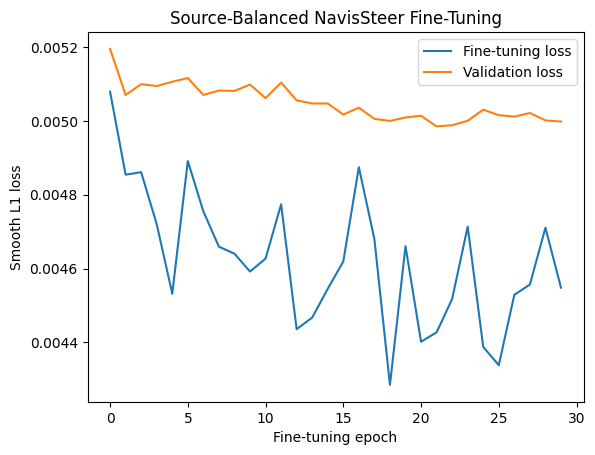

In [ ]:
# Resume NavisSteer checkpoint and fine-tune it on Kaggle + ordinary + recovery CARLA data
# Run the earlier import, data-loader, training-helper, and NavisSteer class cells first.

from torch.utils.data import ConcatDataset, Subset, WeightedRandomSampler

RESUME_CHECKPOINT = Path("/content/drive/MyDrive/NavisAI/models/navissteer_finetuned_best.pt")
NEW_DATA_ROOT = Path("/content/drive/MyDrive/NavisAI/new_data")
RECOVERY_DATA_ROOT = Path("/content/drive/MyDrive/NavisAI/recovery_data")
FINE_TUNE_EPOCHS = 30
FINE_TUNE_LEARNING_RATE = 0.00005
FINE_TUNE_BATCH_SIZE = 256
NEW_DATA_FRAME_STRIDE = 1  # Keep every new frame; increase if too repetitive
RECOVERY_DATA_FRAME_STRIDE = 1  # Keep every corrective recovery frame
TRAIN_SOURCE_PROPORTIONS = {
    "original": 0.50,
    "ordinary_new": 0.20,
    "recovery": 0.30,
}
SPLIT_SEED = 1000


def _numeric_path_key(path):
    digits = "".join(character for character in path.stem if character.isdigit())
    return (int(digits) if digits else float("inf"), path.name)


def load_recorded_steering_dataset(
    data_root,
    image_size=(110, 220),
    frame_stride=1,
):
    """Load recorder output: PNG/JPG images plus steer_values.txt."""
    data_root = Path(data_root)
    image_candidates = [data_root / "images", data_root / "Images", data_root]
    image_dir = next(
        (
            candidate
            for candidate in image_candidates
            if candidate.is_dir()
            and any(
                path.suffix.lower() in {".png", ".jpg", ".jpeg"}
                for path in candidate.iterdir()
                if path.is_file()
            )
        ),
        None,
    )
    if image_dir is None:
        raise FileNotFoundError(
            f"No images found under {data_root}. Place the recorded images directly "
            "there or in an images/ subfolder."
        )

    label_candidates = [
        data_root / "steer_values.txt",
        data_root / "SteerValues" / "steer_values.txt",
        image_dir / "steer_values.txt",
    ]
    labels_path = next((path for path in label_candidates if path.is_file()), None)
    if labels_path is None:
        raise FileNotFoundError(
            f"steer_values.txt was not found under {data_root}."
        )

    image_paths = sorted(
        [
            path
            for path in image_dir.iterdir()
            if path.is_file() and path.suffix.lower() in {".png", ".jpg", ".jpeg"}
        ],
        key=_numeric_path_key,
    )
    steering_values = np.asarray(
        np.loadtxt(labels_path, dtype=np.float32),
        dtype=np.float32,
    ).reshape(-1)

    if len(image_paths) != len(steering_values):
        raise ValueError(
            f"Recorded-data mismatch: {len(image_paths)} images but "
            f"{len(steering_values)} steering values."
        )
    if frame_stride < 1:
        raise ValueError("frame_stride must be at least 1")

    image_paths = image_paths[::frame_stride]
    steering_values = steering_values[::frame_stride]
    height, width = map(int, image_size)
    images_uint8 = torch.empty(
        (len(image_paths), 3, height, width),
        dtype=torch.uint8,
    )

    for index, image_path in enumerate(image_paths):
        with Image.open(image_path) as image:
            image = image.convert("RGB")

            # Recorder output may already be 220x110. If it is 220x220,
            # remove the top half exactly as in the Kaggle preprocessing.
            if image.size == (220, 220):
                image = image.crop((0, 110, 220, 220))
            elif image.size != (width, height):
                image = image.resize((width, height), Image.Resampling.BILINEAR)

            image_array = np.asarray(image, dtype=np.uint8).copy()
            images_uint8[index] = torch.from_numpy(image_array).permute(2, 0, 1)

        if (index + 1) % 1000 == 0 or index + 1 == len(image_paths):
            print(f"Loaded {index + 1:,}/{len(image_paths):,} recorded images")

    return CachedSteeringDataset(
        images_uint8,
        torch.from_numpy(steering_values.copy()),
    )


def split_original_dataset(dataset, seed=SPLIT_SEED):
    """Reproduce the notebook's existing 70/15/15 random split."""
    train_size = int(0.70 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    return random_split(
        dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed),
    )


def split_sequential_recorded_data(dataset):
    """Keep adjacent recorded frames out of different random splits."""
    train_end = int(0.70 * len(dataset))
    val_end = train_end + int(0.15 * len(dataset))
    indices = range(len(dataset))
    return (
        Subset(dataset, list(indices[:train_end])),
        Subset(dataset, list(indices[train_end:val_end])),
        Subset(dataset, list(indices[val_end:])),
    )


def make_source_balanced_sampler(source_datasets):
    """Draw a fixed proportion from each training source every epoch."""
    expected_names = set(TRAIN_SOURCE_PROPORTIONS)
    if set(source_datasets) != expected_names:
        raise ValueError(
            f"Sampler sources {set(source_datasets)} do not match "
            f"configured sources {expected_names}."
        )

    probability_sum = sum(TRAIN_SOURCE_PROPORTIONS.values())
    if not np.isclose(probability_sum, 1.0):
        raise ValueError(
            f"TRAIN_SOURCE_PROPORTIONS must sum to 1.0, got {probability_sum}."
        )

    sample_weights = []
    for source_name, dataset in source_datasets.items():
        source_size = len(dataset)
        if source_size == 0:
            raise ValueError(f"Training source '{source_name}' is empty.")
        per_sample_weight = (
            TRAIN_SOURCE_PROPORTIONS[source_name] / source_size
        )
        sample_weights.append(
            torch.full(
                (source_size,),
                per_sample_weight,
                dtype=torch.double,
            )
        )

    samples_per_epoch = sum(len(dataset) for dataset in source_datasets.values())
    sampler = WeightedRandomSampler(
        weights=torch.cat(sample_weights),
        num_samples=samples_per_epoch,
        replacement=True,
        generator=torch.Generator().manual_seed(SPLIT_SEED),
    )
    return sampler, samples_per_epoch


def make_combined_loaders(batch_size=FINE_TUNE_BATCH_SIZE):
    original_dataset = prepare_steering_cache(
        image_size=img_size,
        frame_stride=STEERING_FRAME_STRIDE,
        input_mode=STEERING_INPUT_MODE,
    )
    new_dataset = load_recorded_steering_dataset(
        NEW_DATA_ROOT,
        image_size=img_size,
        frame_stride=NEW_DATA_FRAME_STRIDE,
    )
    recovery_dataset = load_recorded_steering_dataset(
        RECOVERY_DATA_ROOT,
        image_size=img_size,
        frame_stride=RECOVERY_DATA_FRAME_STRIDE,
    )

    original_train, original_val, original_test = split_original_dataset(
        original_dataset
    )
    new_train, new_val, new_test = split_sequential_recorded_data(new_dataset)
    recovery_train, recovery_val, recovery_test = split_sequential_recorded_data(
        recovery_dataset
    )

    combined_train = ConcatDataset(
        [original_train, new_train, recovery_train]
    )
    combined_val = ConcatDataset([original_val, new_val, recovery_val])
    combined_test = ConcatDataset([original_test, new_test, recovery_test])

    training_sources = {
        "original": original_train,
        "ordinary_new": new_train,
        "recovery": recovery_train,
    }
    train_sampler, samples_per_epoch = make_source_balanced_sampler(
        training_sources
    )

    loader_options = dict(
        batch_size=batch_size,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )
    train_loader = DataLoader(
        combined_train,
        sampler=train_sampler,
        **loader_options,
    )
    val_loader = DataLoader(combined_val, shuffle=False, **loader_options)
    test_loader = DataLoader(combined_test, shuffle=False, **loader_options)

    print(
        f"Original samples: {len(original_dataset):,} | "
        f"ordinary new samples: {len(new_dataset):,} | "
        f"recovery samples: {len(recovery_dataset):,}"
    )
    print(
        f"Combined splits: train={len(combined_train):,}, "
        f"validation={len(combined_val):,}, test={len(combined_test):,}"
    )
    print(f"Balanced training draws per epoch: {samples_per_epoch:,}")
    for source_name, proportion in TRAIN_SOURCE_PROPORTIONS.items():
        expected_draws = round(samples_per_epoch * proportion)
        print(
            f"  {source_name}: {proportion:.0%} "
            f"(~{expected_draws:,} samples/epoch)"
        )
    return train_loader, val_loader, test_loader


def load_navissteer_checkpoint(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.is_file():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}. "
            "Copy navissteer_best.pt to this Google Drive location."
        )

    try:
        payload = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True,
        )
    except TypeError:
        payload = torch.load(checkpoint_path, map_location=device)

    model = NavisSteer().to(device)
    state_dict = (
        payload["model_state_dict"]
        if isinstance(payload, dict) and "model_state_dict" in payload
        else payload
    )
    model.load_state_dict(state_dict, strict=True)

    if isinstance(payload, dict):
        checkpoint_size = tuple(payload.get("image_size", img_size))
        checkpoint_channels = int(payload.get("input_channels", 3))
        if checkpoint_size != tuple(img_size) or checkpoint_channels != 3:
            raise ValueError(
                f"Checkpoint expects {checkpoint_channels} channels at "
                f"{checkpoint_size}, but this notebook uses 3 channels at "
                f"{tuple(img_size)}."
            )
        print(
            f"Loaded {checkpoint_path.name} from epoch "
            f"{payload.get('epoch', 'unknown')} "
            f"(validation loss={payload.get('validation_loss', payload.get('validation_mse', 'unknown'))})."
        )
    else:
        print(f"Loaded legacy state_dict from {checkpoint_path}.")

    return model, payload


def fine_tune_navissteer(
    checkpoint_path=RESUME_CHECKPOINT,
    num_epochs=FINE_TUNE_EPOCHS,
    learning_rate=FINE_TUNE_LEARNING_RATE,
    batch_size=FINE_TUNE_BATCH_SIZE,
):
    model, source_payload = load_navissteer_checkpoint(checkpoint_path)
    train_loader, val_loader, test_loader = make_combined_loaders(batch_size)

    criterion = nn.SmoothL1Loss(beta=0.05)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )
    amp_enabled = bool(device.type == "cuda")
    scaler = _new_grad_scaler(amp_enabled)

    old_epoch = (
        int(source_payload.get("epoch", 0))
        if isinstance(source_payload, dict)
        else 0
    )
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")

    output_dir = Path("/content/drive/MyDrive/NavisAI/models")
    output_dir.mkdir(parents=True, exist_ok=True)
    best_path = output_dir / "navissteer_finetuned_best.pt"
    final_path = output_dir / "navissteer_finetuned_final.pt"

    def save_resume_checkpoint(path, completed_epoch, validation_loss):
        temporary_path = path.with_suffix(path.suffix + ".tmp")
        torch.save(
            {
                "checkpoint_version": 3,
                "model_name": "NavisSteer",
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "epoch": int(completed_epoch),
                "fine_tune_epochs": int(num_epochs),
                "validation_loss": float(validation_loss),
                "image_size": tuple(img_size),
                "input_height": int(img_size[0]),
                "input_width": int(img_size[1]),
                "input_channels": 3,
                "input_mode": STEERING_INPUT_MODE,
                "roi_crop": tuple(STEERING_ROI_CROP),
                "pixel_range": (0.0, 1.0),
                "base_frame_stride": int(STEERING_FRAME_STRIDE),
                "new_data_frame_stride": int(NEW_DATA_FRAME_STRIDE),
                "recovery_data_frame_stride": int(RECOVERY_DATA_FRAME_STRIDE),
                "train_source_proportions": dict(TRAIN_SOURCE_PROPORTIONS),
                "split_seed": int(SPLIT_SEED),
                "batch_size": int(batch_size),
                "learning_rate": float(learning_rate),
                "source_checkpoint": str(checkpoint_path),
                "train_losses": list(train_losses),
                "val_losses": list(val_losses),
            },
            temporary_path,
        )
        os.replace(temporary_path, path)

    def average_loss(loader, training):
        model.train(training)
        total_loss = 0.0
        total_samples = 0

        context = torch.enable_grad() if training else torch.inference_mode()
        with context:
            for images, targets in loader:
                images, targets = _steering_batch_to_device(images, targets)

                if training:
                    optimizer.zero_grad(set_to_none=True)

                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=amp_enabled,
                ):
                    predictions = model(images)
                    loss = criterion(predictions, targets)

                if training:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()

                total_loss += loss.detach().float().item() * images.size(0)
                total_samples += images.size(0)

        return total_loss / max(total_samples, 1)

    baseline_val_loss = average_loss(val_loader, training=False)
    best_val_loss = baseline_val_loss

    print(f"Loaded-checkpoint validation loss: {baseline_val_loss:.6f}")

    started = time.time()
    for fine_tune_epoch in range(1, num_epochs + 1):
        train_loss = average_loss(train_loader, training=True)
        val_loss = average_loss(val_loader, training=False)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        absolute_epoch = old_epoch + fine_tune_epoch
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_resume_checkpoint(best_path, absolute_epoch, val_loss)
            print(f"Saved new best fine-tuned checkpoint: {best_path}")

        print(
            f"Fine-tune epoch {fine_tune_epoch:02d}/{num_epochs} | "
            f"train loss={train_loss:.6f} | val loss={val_loss:.6f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

    save_resume_checkpoint(
        final_path,
        old_epoch + num_epochs,
        val_losses[-1],
    )

    try:
        best_payload = torch.load(
            best_path,
            map_location=device,
            weights_only=True,
        )
    except TypeError:
        best_payload = torch.load(best_path, map_location=device)
    model.load_state_dict(best_payload["model_state_dict"])
    model.eval()

    squared_error_sum = 0.0
    absolute_error_sum = 0.0
    target_count = 0
    with torch.inference_mode():
        for images, targets in test_loader:
            images, targets = _steering_batch_to_device(images, targets)
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)
            errors = predictions.float() - targets.float()
            squared_error_sum += errors.square().sum().item()
            absolute_error_sum += errors.abs().sum().item()
            target_count += targets.numel()

    test_mse = squared_error_sum / max(target_count, 1)
    test_mae = absolute_error_sum / max(target_count, 1)

    print(f"Fine-tuning took {(time.time() - started) / 60:.2f} minutes.")
    print(f"Combined test MSE={test_mse:.6f} | MAE={test_mae:.6f}")
    print(f"Best checkpoint: {best_path}")
    print(f"Final checkpoint: {final_path}")

    plt.plot(train_losses, label="Fine-tuning loss")
    plt.plot(val_losses, label="Validation loss")
    plt.xlabel("Fine-tuning epoch")
    plt.ylabel("Smooth L1 loss")
    plt.title("Source-Balanced NavisSteer Fine-Tuning")
    plt.legend()
    plt.show()

    return model, train_losses, val_losses


# Start from the saved weights; this does not retrain from scratch.
navissteer_finetuned_model, finetune_train_losses, finetune_val_losses = (
    fine_tune_navissteer()
)


# Get Accuracy

In [ ]:
navissteer_accuracy = steering_accuracy_report(
    navissteer_finetuned_model,
    model_name="NavisSteer CNN",
    batch_size=256,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
)

Steering samples: train=15,136, validation=3,243, test=3,244; input_mode=roi; image_size=(110, 220); frame_stride=4; uint8 cache=True

NavisSteer CNN test-set performance
---------------------------------------------
Test samples:              3,244
MSE:                       0.001392
RMSE:                      0.037313
MAE:                       0.014361
R²:                        0.8336
Accuracy within ±0.05:     93.25%
Accuracy within ±0.10:     97.29%


# Evaluate Model on New Data

NavisSteer fine-tuned V2 New Unseen Data CARLA evaluation
----------------------------------------------------------
Checkpoint epoch:             153
Evaluation samples:           2,330
MSE:                          0.000625
RMSE:                         0.024998
MAE:                          0.018595
Accuracy within ±0.05:        94.89%
Accuracy within ±0.10:        99.83%
Mean signed error:            -0.006216
Maximum absolute error:       0.114597



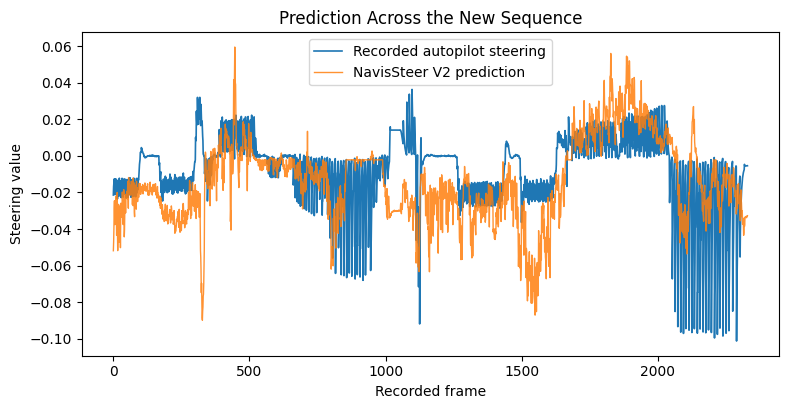

In [ ]:
# Evaluate the frozen fine-tuned NavisSteer V2 checkpoint on untouched CARLA data.
# This cell performs inference only: it does not train, split, or modify the model.
from pathlib import Path
import math

import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
from PIL import Image
import matplotlib.pyplot as plt

NEW_DATA_ROOT = Path("/content/drive/MyDrive/NavisAI/new_data")
NAVISSTEER_V2_CHECKPOINT = Path(
    "/content/drive/MyDrive/NavisAI/models/navissteer_finetuned_bestV2.pt"
)
NEW_DATA_BATCH_SIZE = 256
NEW_DATA_IMAGE_SIZE = (110, 220)  # H, W
NEW_DATA_NUM_WORKERS = 2


def _recording_numeric_key(path):
    digits = "".join(character for character in path.stem if character.isdigit())
    return (int(digits) if digits else float("inf"), path.name)


class UntouchedCarlaSteeringDataset(Dataset):
    """Load one untouched CARLA recording without augmentation or subsampling."""

    IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}

    def __init__(self, root, image_size=(110, 220)):
        self.root = Path(root)
        self.image_size = tuple(map(int, image_size))

        image_candidates = [
            self.root / "images",
            self.root / "Images",
            self.root,
        ]
        self.image_dir = next(
            (
                candidate
                for candidate in image_candidates
                if candidate.is_dir()
                and any(
                    path.is_file()
                    and path.suffix.lower() in self.IMAGE_EXTENSIONS
                    for path in candidate.iterdir()
                )
            ),
            None,
        )
        if self.image_dir is None:
            raise FileNotFoundError(
                f"No PNG/JPG images were found under {self.root}."
            )

        label_candidates = [
            self.root / "steer_values.txt",
            self.root / "SteerValues" / "steer_values.txt",
            self.image_dir / "steer_values.txt",
        ]
        self.labels_path = next(
            (path for path in label_candidates if path.is_file()),
            None,
        )
        if self.labels_path is None:
            raise FileNotFoundError(
                f"steer_values.txt was not found under {self.root}."
            )

        self.image_paths = sorted(
            [
                path
                for path in self.image_dir.iterdir()
                if path.is_file()
                and path.suffix.lower() in self.IMAGE_EXTENSIONS
            ],
            key=_recording_numeric_key,
        )
        self.steering_values = np.asarray(
            np.loadtxt(self.labels_path, dtype=np.float32),
            dtype=np.float32,
        ).reshape(-1)

        if len(self.image_paths) != len(self.steering_values):
            raise ValueError(
                f"New-data mismatch: {len(self.image_paths):,} images but "
                f"{len(self.steering_values):,} steering values."
            )
        if not self.image_paths:
            raise ValueError("The new-data recording is empty.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        height, width = self.image_size
        with Image.open(self.image_paths[index]) as image:
            image = image.convert("RGB")

            # Recorder output may already be the 220x110 ROI. If a full
            # 220x220 frame is supplied, remove its upper half identically
            # to NavisSteer's training and real-time preprocessing.
            if image.size == (220, 220):
                image = image.crop((0, 110, 220, 220))
            elif image.size != (width, height):
                image = image.resize(
                    (width, height),
                    Image.Resampling.BILINEAR,
                )

            image_uint8 = TF.pil_to_tensor(image)

        target = torch.tensor(
            self.steering_values[index],
            dtype=torch.float32,
        )
        return image_uint8, target


def evaluate_navissteer_v2_on_new_data():
    if not NAVISSTEER_V2_CHECKPOINT.is_file():
        raise FileNotFoundError(
            f"Checkpoint not found: {NAVISSTEER_V2_CHECKPOINT}"
        )

    dataset = UntouchedCarlaSteeringDataset(
        NEW_DATA_ROOT,
        image_size=NEW_DATA_IMAGE_SIZE,
    )
    loader_options = dict(
        batch_size=NEW_DATA_BATCH_SIZE,
        shuffle=False,
        num_workers=NEW_DATA_NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    if NEW_DATA_NUM_WORKERS > 0:
        loader_options.update(
            persistent_workers=True,
            prefetch_factor=2,
        )
    loader = DataLoader(dataset, **loader_options)

    try:
        checkpoint = torch.load(
            NAVISSTEER_V2_CHECKPOINT,
            map_location=device,
            weights_only=True,
        )
    except TypeError:
        checkpoint = torch.load(
            NAVISSTEER_V2_CHECKPOINT,
            map_location=device,
        )

    if not isinstance(checkpoint, dict) or "model_state_dict" not in checkpoint:
        raise ValueError(
            "Expected a NavisSteer checkpoint dictionary containing "
            "model_state_dict."
        )

    checkpoint_size = tuple(
        checkpoint.get("image_size", NEW_DATA_IMAGE_SIZE)
    )
    checkpoint_channels = int(checkpoint.get("input_channels", 3))
    if checkpoint_size != NEW_DATA_IMAGE_SIZE or checkpoint_channels != 3:
        raise ValueError(
            f"Checkpoint expects {checkpoint_channels} channels at "
            f"{checkpoint_size}, but this evaluator uses RGB images at "
            f"{NEW_DATA_IMAGE_SIZE}."
        )

    model = NavisSteer().to(device)
    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    model.eval()

    predictions_all = []
    targets_all = []
    amp_enabled = device.type == "cuda"

    with torch.inference_mode():
        for images_uint8, targets in loader:
            images = images_uint8.to(device, non_blocking=True)
            images = images.float().div_(255.0)
            targets = targets.to(
                device,
                non_blocking=True,
                dtype=torch.float32,
            ).view(-1)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images).view(-1)

            predictions_all.append(predictions.float().cpu())
            targets_all.append(targets.float().cpu())

    predictions = torch.cat(predictions_all)
    targets = torch.cat(targets_all)
    errors = predictions - targets
    absolute_errors = errors.abs()

    mse = errors.square().mean().item()
    rmse = math.sqrt(mse)
    mae = absolute_errors.mean().item()
    target_variation = ((targets - targets.mean()) ** 2).sum().item()
    residual_variation = errors.square().sum().item()
    r_squared = (
        1.0 - residual_variation / target_variation
        if target_variation > 0.0
        else float("nan")
    )
    accuracy_005 = (
        100.0 * (absolute_errors <= 0.05).float().mean().item()
    )
    accuracy_010 = (
        100.0 * (absolute_errors <= 0.10).float().mean().item()
    )
    mean_error = errors.mean().item()
    maximum_absolute_error = absolute_errors.max().item()

    results = {
        "model": "NavisSteer fine-tuned V2",
        "checkpoint": str(NAVISSTEER_V2_CHECKPOINT),
        "checkpoint_epoch": checkpoint.get("epoch", "unknown"),
        "test_samples": len(dataset),
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r_squared": r_squared,
        "accuracy_within_0.05": accuracy_005,
        "accuracy_within_0.10": accuracy_010,
        "mean_error": mean_error,
        "maximum_absolute_error": maximum_absolute_error,
    }

    print("NavisSteer fine-tuned V2 New Unseen Data CARLA evaluation")
    print("-" * 58)
    print(f"Checkpoint epoch:             {results['checkpoint_epoch']}")
    print(f"Evaluation samples:           {len(dataset):,}")
    print(f"MSE:                          {mse:.6f}")
    print(f"RMSE:                         {rmse:.6f}")
    print(f"MAE:                          {mae:.6f}")
    print(f"Accuracy within ±0.05:        {accuracy_005:.2f}%")
    print(f"Accuracy within ±0.10:        {accuracy_010:.2f}%")
    print(f"Mean signed error:            {mean_error:.6f}")
    print(f"Maximum absolute error:       {maximum_absolute_error:.6f}")
    print()

    frame_indices = np.arange(len(targets))
    figure, ax = plt.subplots(figsize=(9, 4.2))

    ax.plot(
        frame_indices,
        targets.numpy(),
        label="Recorded autopilot steering",
        linewidth=1.2,
    )
    ax.plot(
        frame_indices,
        predictions.numpy(),
        label="NavisSteer V2 prediction",
        linewidth=1.0,
        alpha=0.85,
    )
    ax.set_xlabel("Recorded frame")
    ax.set_ylabel("Steering value")
    ax.set_title("Prediction Across the New Sequence")
    ax.legend()
    plt.show()

    return results, predictions, targets


navissteer_v2_new_data_metrics, new_data_predictions, new_data_targets = (
    evaluate_navissteer_v2_on_new_data()
)
